# Bayesian inference comparison for per-pixel forest-growth prediction

*Group 2 — Alexander Hagedorn, Søren Mondrup, Claes Rasmus Peter Weibull · DTU 42186, Spring 2026*


## Overview

This notebook is the empirical backbone of the report (§3–§5): Swedish lidar and species rasters on a $5\,\mathrm{km} \times 5\,\mathrm{km}$ AOI → CLR-transformed species composition and a 2-factor Bayesian factor analysis of the collinear lidar block (§3) → BK-cell-disjoint train/test splits on a nested scaling grid (§4) → OLS / GBM baselines (§5) → a Bayesian model sequence (§6: BLR fit by Exact / SVI / NUTS, LogNormal likelihood, mean-structure extensions, BNN) → unified comparison on five evaluation dimensions (§7).


In [1]:
from __future__ import annotations
from pathlib import Path
import json
import urllib.request

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

SEED = 42
np.random.seed(SEED)

# Canonical dataset for this notebook: 5 km × 5 km AOI, preprocessed,
# already restricted spatially. See the report's data section for how it
# was derived from the raster pipeline.
CSV_PATH = Path("out_5km_idx_preprocessed.csv")
CSV_URL = (
    "https://github.com/Somon8/mbml-forest-pipeline/"
    "releases/download/v2.0-data-5km/out_5km_idx_preprocessed.csv"
)
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)
SPLITS_JSON = CACHE_DIR / "splits_5km.json"

if not CSV_PATH.exists():
    print(f"CSV missing — downloading from {CSV_URL} ...")
    urllib.request.urlretrieve(CSV_URL, CSV_PATH)
    print(f"  → wrote {CSV_PATH} ({CSV_PATH.stat().st_size/1e6:.0f} MB)")

## 1. Load and filter

The CSV (`out_5km_idx_preprocessed.csv`) is the preprocessed Swedish-forest dataset at $12.5\,\mathrm{m}$ resolution, restricted to the $5\,\mathrm{km} \times 5\,\mathrm{km}$ AOI. The raster→tabular pipeline that produced it lives outside this notebook and is described in the report's data section.

One filter is applied: **`is_stable_forest`** drops pixels that are non-forest in either inventory cycle, are water (lakes), or lost biomass / height / volume between cycles. This restricts modelling to the support on which $\Delta V$ is defined, continuous, and non-negative.


In [2]:
# Swedish raster column names → readable English.
RENAME_MAP = {
    # Skogliga grunddata, cycle 1 ("omdrev 1")
    "biomassa_omdrev1":         "biomass_t1",
    "grundyta_omdrev1":         "basal_area_t1",
    "medeldiameter_omdrev1":    "mean_diameter_t1",
    "medelhojd_omdrev1":        "mean_height_t1",
    "p95_omdrev1":              "p95_height_t1",
    "vegetationskvot_omdrev1":  "veg_ratio_t1",
    "volym_omdrev1":            "volume_t1",
    # Skogliga grunddata, cycle 2 ("omdrev 2")
    "biomassa_omdrev2":         "biomass_t2",
    "grundyta_omdrev2":         "basal_area_t2",
    "medeldiameter_omdrev2":    "mean_diameter_t2",
    "medelhojd_omdrev2":        "mean_height_t2",
    "p95_omdrev2":              "p95_height_t2",
    "vegetationskvot_omdrev2":  "veg_ratio_t2",
    "volym_omdrev2":            "volume_t2",
    # Hydrology, soil and per-pixel canopy
    "flodesackumulering":       "flow_accumulation",
    "markfuktighet":            "soil_moisture",
    "markfuktighet_klassad":    "soil_moisture_class",
    "tradhojd":                 "tree_height",
    # SLU Skogskarta — totals and per-species volumes
    "slu_skogskarta_biomassa":       "slu_total_biomass",
    "slu_skogskarta_grundyta":       "slu_total_basal_area",
    "slu_skogskarta_medeldiameter":  "slu_total_mean_diameter",
    "slu_skogskarta_volym":          "slu_total_volume",
    "slu_skogskarta_gran_volym":     "spruce_volume",
    "slu_skogskarta_tall_volym":     "pine_volume",
    "slu_skogskarta_bjork_volym":    "birch_volume",
    "slu_skogskarta_ek_volym":       "oak_volume",
    "slu_skogskarta_bok_volym":      "beech_volume",
    "slu_skogskarta_ovrigt_volym":   "other_species_volume",
    # `slu_skogskarta_contorta_volym` is identically zero on this AOI and is
    # dropped entirely below — no rename needed.
}

df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df_raw = df_raw.rename(columns=RENAME_MAP)
df_raw = df_raw.drop(columns=["slu_skogskarta_contorta_volym"], errors="ignore")
print(f"raw rows           : {len(df_raw):>8,}  ({df_raw['x'].nunique()} × {df_raw['y'].nunique()} grid)")

df = df_raw[df_raw["is_stable_forest"].astype(bool)].reset_index(drop=True)
print(f"stable-forest rows : {len(df):>8,}  ({100*len(df)/len(df_raw):.1f}% of grid)")
print(f"unique BK cells    : {df['BK'].nunique():>8,}")

raw rows           :  160,000  (400 × 400 grid)
stable-forest rows :   63,073  (39.4% of grid)
unique BK cells    :      121


The `is_stable_forest` filter removes ~60 % of pixels; the ~63 000 survivors span 121 BK indexruta cells, the unit of the train/test split (§4).


## 2. Feature matrix and target

**Target — volume growth.** $\Delta V = \texttt{volume\_t2} - \texttt{volume\_t1}$ is per-pixel change in stem volume between inventory cycles, in m³/ha. On the stable-forest support it is non-negative, continuous, and right-skewed.

**Features — 16 columns:**

1. **Forest state at cycle 1 (10 cols, raw):** seven lidar-derived cycle-1 summaries (`biomass_t1`, `basal_area_t1`, `mean_diameter_t1`, `mean_height_t1`, `p95_height_t1`, `veg_ratio_t1`, `volume_t1`), plus `flow_accumulation`, `soil_moisture`, and `slu_total_biomass`. Cycle-2 columns are deliberately excluded — they would leak the target.
2. **Species composition (6 cols, CLR-transformed):** the six SLU per-species stem volumes present on this AOI (`spruce_volume`, `pine_volume`, `birch_volume`, `oak_volume`, `beech_volume`, `other_species_volume`). They sum to total volume by construction, so the centred log-ratio $p_i \mapsto \log(p_i / g(p))$ lifts the block off the simplex into $\mathbb{R}^6$ where independent linear coefficients are well-defined. Lodgepole pine is identically zero across this AOI and is dropped at load time to avoid distorting the geometric mean.

`volume_t1` appears in both blocks *and* in the target — that is intentional: we model growth conditional on initial volume, as a textbook $\Delta V = f(V_1, \text{covariates}) - V_1$ growth equation would. Standardisation of $\mathbf{X}$ and $y$ happens inside `slice_step` (§4.2) using training-set statistics only.


In [3]:
BASE_COLS = [
    "biomass_t1", "basal_area_t1", "mean_diameter_t1",
    "mean_height_t1", "p95_height_t1", "veg_ratio_t1",
    "volume_t1", "flow_accumulation", "soil_moisture",
    "slu_total_biomass",
]
SPECIES_COLS = [
    "spruce_volume", "pine_volume", "birch_volume",
    "oak_volume", "beech_volume", "other_species_volume",
]


def clr_transform(values: np.ndarray, eps: float = 1e-9) -> np.ndarray:
    row_sums = values.sum(axis=1, keepdims=True)
    nz = row_sums.ravel() > 0
    props = np.where(row_sums > 0, values / np.where(row_sums > 0, row_sums, 1.0), 0.0)
    props_safe = np.where(props <= 0, eps, props)
    log_props = np.log(props_safe)
    clr = log_props - log_props.mean(axis=1, keepdims=True)
    clr[~nz] = 0.0
    return clr


X_base = df[BASE_COLS].to_numpy(float)
X_clr = clr_transform(df[SPECIES_COLS].to_numpy(float))
X_all = np.hstack([X_base, X_clr])
FEATURE_NAMES = BASE_COLS + [c + "_clr" for c in SPECIES_COLS]

# Target: per-pixel change in stem volume between inventory cycles (m³/ha).
# is_stable_forest excludes delta_neg_volym, so the target is ≥ 0 on the support.
y_all = (df["volume_t2"] - df["volume_t1"]).to_numpy(float)
coords_all = df[["x", "y"]].to_numpy(float)
bk_all = df["BK"].to_numpy()

print(f"X_all   : {X_all.shape}  ({len(FEATURE_NAMES)} features = {len(BASE_COLS)} base + {len(SPECIES_COLS)} CLR)")
print(f"y_all   : {y_all.shape}  mean={y_all.mean():.2f} m³/ha  std={y_all.std():.2f} m³/ha")
print(f"coords  : {coords_all.shape}")

X_all   : (63073, 16)  (16 features = 10 base + 6 CLR)
y_all   : (63073,)  mean=52.07 m³/ha  std=44.57 m³/ha
coords  : (63073, 2)


**Reading the output.** Design matrix is $\sim\!63\,000 \times 16$. Target mean ($\sim\!52\,\mathrm{m^3/ha}$) and standard deviation ($\sim\!45\,\mathrm{m^3/ha}$) bracket a decade of typical Swedish-forest mean-annual-increment ($5{-}10\,\mathrm{m^3/ha/year}$). All values positive on the stable-forest support, as expected.


## 3. Benchmarking framework

Every model in §5–§6 is evaluated through the same machinery: BK-cell-disjoint splits on a nested scaling grid (§4.1), a single `slice_step` utility that returns standardised train/test data (§4.2), and a five-dimension evaluation framework (§4.3) that scores each fit on point accuracy, what it learned, calibration, residual structure, and wall-clock compute.


### 3.1 BK-cell-disjoint splits on a nested scaling grid

Skogsstyrelsen publishes a $500\,\mathrm{m} \times 500\,\mathrm{m}$ administrative grid (the *Sverige-indexruta*, BK); every pixel in our CSV is labelled with the BK cell that contains it. Pixels inside one BK cell are often near-identical — same stand, same management history, same soil class — so a random pixel split would put a held-out pixel next to its ~1 600 quasi-twins on the training side and inflate $R^2$ by tens of percent. **Splitting by BK cell** prevents that: every test pixel is in a BK cell containing no training pixel. This kills within-cell leakage but not across-cell autocorrelation, which the Moran's I statistic in §4.3 measures and which the §6.2 spatial models try to absorb.

From the 121 BK cells in the AOI, 24 (≈ 20 %) are picked once by a seeded random draw as the **test set** — never seen by any model at any scaling step. The remaining 97 form the **training pool**, kept in a seeded random order. The same 24-cell test set is used everywhere downstream, so RMSEs are directly comparable across models and scaling steps.

A scaling step `n_cells = k` trains on the **first $k$ cells of the 97-cell pool**, against the same 24-cell test set. Because the pool is ordered once and never reshuffled, $5 \subset 25 \subset 50 \subset 97$ — each step adds data of the same kind rather than redrawing a fresh sample, so the scaling axis isolates the marginal value of additional training data from sample-to-sample variance.


In [4]:
from notebook_helpers import load_or_build_splits, get_train_bk

TEST_FRAC = 0.20
splits = load_or_build_splits(df, SPLITS_JSON, TEST_FRAC, SEED)

# Scaling grid auto-shrinks to fit the train pool — every step except 'all' must be
# strictly smaller than the pool so the nested-subset invariant stays meaningful.
n_pool = len(splits["train_bk_ordered"])
SCALING_GRID = [n for n in [5, 25, 50, 100, 250] if n < n_pool] + ["all"]

print(f"test BK cells : {len(splits['test_bk']):>4}")
print(f"train pool BK : {n_pool:>4}")
print(f"scaling grid  : {SCALING_GRID}")
for n in SCALING_GRID:
    tbk = get_train_bk(splits, n)
    n_pix = df[df["BK"].isin(set(tbk))].shape[0]
    print(f"  n_cells={str(n):>4}  -> {len(tbk):>4} BK cells, {n_pix:>7,} pixels")


loaded splits from cache/splits_5km.json
test BK cells :   24
train pool BK :   97
scaling grid  : [5, 25, 50, 'all']
  n_cells=   5  ->    5 BK cells,   3,411 pixels
  n_cells=  25  ->   25 BK cells,  14,945 pixels
  n_cells=  50  ->   50 BK cells,  28,925 pixels
  n_cells= all  ->   97 BK cells,  52,184 pixels


/Users/mondrup/.venvs/ml42186-proj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# nesting + disjointness sanity checks
subsets = [set(get_train_bk(splits, n)) for n in SCALING_GRID]
for i in range(len(subsets) - 1):
    assert subsets[i].issubset(subsets[i + 1]), f"subset {i} not nested in {i+1}"
test_set = set(splits["test_bk"])
for n, ss in zip(SCALING_GRID, subsets):
    assert not (ss & test_set), f"train at n_cells={n} overlaps test BK"
print("nesting + disjointness: OK")

nesting + disjointness: OK


**Reading the output.** 24 test BK cells, 97 in the training pool, drawn in nested chunks 5 → 25 → 50 → 97. Pixel counts track the BK count at ~540 pixels per cell.


### 3.2 `slice_step` — the one entry point for train/test data

Every model in §5–§6 reads its data through this helper. `slice_step(n_cells)` returns standardised `X_train / y_train / X_test / y_test` (training-set statistics only — no test leakage), `coords_test` for Moran's I, and the rescaling constants `y_mean, y_std`. The optional `X` argument lets §5 evaluate OLS on the FA-reduced design on the same BK split.


In [6]:
from notebook_helpers import make_slicer
slice_step = make_slicer(X_all, y_all, coords_all, bk_all, splits)


### 3.3 Evaluation framework — the five dimensions

Every model in §5–§6 is scored on the same five axes so the §7 comparison stays apples-to-apples. All metrics are computed in original units (m³/ha) after un-standardising predictions; each fit registers its results into the shared `MODELS` dictionary that §7 reads.

1. **Point accuracy.** RMSE, MAE, Bias, $R^2$, Pearson correlation on test pixels — the standard regression scorecard.
2. **What the model learned.** Coefficient posteriors — the §7 forest plot and the Exact / SVI / NUTS posterior-density overlay diagnose any disagreement between inference methods.
3. **Uncertainty calibration.** Does the 90 % posterior-predictive interval cover ~90 % of test points? Point-estimate models (OLS, GBM) cannot appear here.
4. **Where residuals concentrate.** Spatial residual maps and residuals-vs-covariate scatters, anchored by **Moran's I on test residuals** with $k=8$ nearest neighbours and row-standardised weights:
$$I = \frac{\sum_i z_i\,\overline{z_{N(i)}}}{\sum_i z_i^2},\qquad z_i = r_i - \bar r,$$
where $r_i$ is the test residual. $I \approx 0$ means residuals look spatially random; $I$ substantially positive means spatial structure the model failed to absorb. The $p$-value comes from a 999-step permutation test, and the diagnostic motivates the §6.2 mean-structure extensions.
5. **Wall-clock compute.** Every fit registers `wall_time_s`; critical for the deployment recommendation.


In [7]:
from notebook_helpers import moran_i, evaluate, MODELS, register_run, all_metrics_df

# Drop any state from a previous kernel run before models start registering below.
MODELS.clear()
print(f'MODELS registry ready (currently {len(MODELS)} entries)')


MODELS registry ready (currently 0 entries)


## 4. Latent stand-state — six collinear lidar views collapse to two factors

The six lidar views pair-correlate at $\rho > 0.85$ within a single inventory cycle — six readouts of one underlying lidar quantity. We compress them with a 2-factor Bayesian factor analysis, identified by the Anderson–Rubin lower-triangular constraint (biomass pins $z_{\text{mass}}$; mean height anchors $z_{\text{geom}}$ with positive loading). FA is fit on training-BK rows only; factor scores for every pixel are computed analytically afterwards. Derivation and prior choices live in §3.2 of the report; implementation is in `notebook_helpers.py`.


In [8]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from notebook_helpers import (FACTOR_VIEWS, VIEW_LABELS, K_DEFAULT, J_DEFAULT,
                        fit_factor_model, posterior_loadings,
                        implied_corr, score_factors_ar)

K, J = K_DEFAULT, J_DEFAULT  # 6 views, 2 latents

# Train-only fit: loadings never see test BK cells.
is_train_row = ~np.isin(bk_all, list(splits['test_bk']))
Y_raw_views  = df[FACTOR_VIEWS].to_numpy(np.float32)
Y_train_v    = Y_raw_views[is_train_row]

Y_mean_views = Y_train_v.mean(0)
Y_std_views  = Y_train_v.std(0) + 1e-8
Y_train_z    = (Y_train_v - Y_mean_views) / Y_std_views
Y_t          = torch.tensor(Y_train_z)

print(f'FA training rows : {Y_train_v.shape[0]:>7,}  ({K} views)')
print(f'all rows         : {Y_raw_views.shape[0]:>7,}  (scored analytically after fit)')


FA training rows :  52,184  (6 views)
all rows         :  63,073  (scored analytically after fit)


  step     0  -ELBO = 641,771
  step  1000  -ELBO = -3,668
  step  2000  -ELBO = -31,611
  step  3000  -ELBO = -40,055
  step  4000  -ELBO = -43,296
  step  5000  -ELBO = -45,334
  step  5999  -ELBO = -46,062


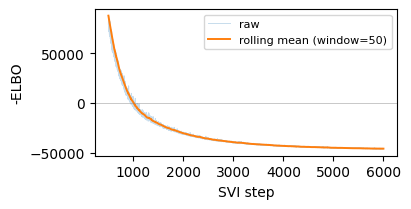

In [9]:
guide_fa, losses_fa, factor_model_2 = fit_factor_model(Y_t, K=K, J=J, n_steps=6000)

# ELBO trajectory (linear y; smoothed because the per-step gradient is noisy near zero).
fig, ax = plt.subplots(figsize=(4.2, 2.2))
losses_arr = np.asarray(losses_fa)
win = 50
smooth = np.convolve(losses_arr, np.ones(win) / win, mode='valid')
WARMUP = 500
ax.plot(np.arange(WARMUP, len(losses_arr)), losses_arr[WARMUP:], alpha=0.25, lw=0.7, label='raw')
ax.plot(np.arange(max(WARMUP, win - 1), len(losses_arr)), smooth[max(0, WARMUP - (win-1)):],
        lw=1.4, label=f'rolling mean (window={win})')
ax.axhline(0, color='gray', lw=0.5, alpha=0.6)
ax.set_xlabel('SVI step'); ax.set_ylabel('-ELBO')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout(); plt.show()


In [10]:
post = posterior_loadings(factor_model_2, guide_fa, Y_t,
                          K=K, J=J, view_labels=VIEW_LABELS, num_samples=400)
Lam_post, sig_post = post['Lam_post'], post['sig_post']
Lam_mean, sig_mean = post['Lam_mean'], post['sig_mean']
mu_mean            = post['mu_mean']

print(post['loading_df'].to_string(index=False))


view  lam_mass  lam_mass_sd  lam_geom  lam_geom_sd  sigma  frac_var
 bio     1.000        0.000     0.000        0.000  0.016     1.000
  CH     0.849        0.001     0.374        0.001  0.042     0.998
  BA     0.953        0.002     0.067        0.002  0.243     0.939
 vol     1.005        0.001    -0.065        0.001  0.111     0.988
diam     0.795        0.001     0.445        0.001  0.120     0.983
 p95     0.857        0.001     0.358        0.001  0.042     0.998


**Reading the table.** Biomass and CH are identification anchors, not hypotheses — the zeros and the positivity constraint are imposed by construction. The four free rows match the mass/geometry split as expected: BA and vol load almost exclusively on $z_{\text{mass}}$ ($|\lambda_{\text{geom}}| < 0.08$); diameter (0.45) and p95 (0.37) carry $z_{\text{geom}}$. `frac_var` $> 0.93$ for all six views.


2-factor : mean |residual rho| off-diag = 0.011   max |residual| = 0.032


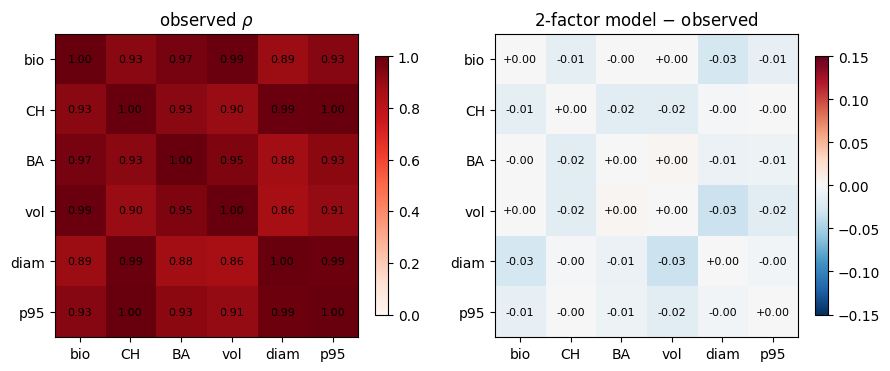

In [11]:
C_model = implied_corr(Lam_post, sig_post)
C_obs   = np.corrcoef(Y_train_z, rowvar=False)
R       = C_model - C_obs

iu = np.triu_indices(K, k=1)
print(f'2-factor : mean |residual rho| off-diag = {np.abs(R[iu]).mean():.3f}'
      f'   max |residual| = {np.abs(R[iu]).max():.3f}')

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.6), constrained_layout=True)
for ax, (title, M, vmin, vmax, cmap) in zip(axes, [
    ('observed $\\rho$',            C_obs, 0.0,  1.0, 'Reds'),
    ('2-factor model $-$ observed', R,    -0.15, 0.15, 'RdBu_r')]):
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(K)); ax.set_xticklabels(VIEW_LABELS)
    ax.set_yticks(range(K)); ax.set_yticklabels(VIEW_LABELS)
    fmt = '{:+.2f}' if '$-$' in title else '{:.2f}'
    for i in range(K):
        for j in range(K):
            ax.text(j, i, fmt.format(M[i, j]), ha='center', va='center', fontsize=8)
    ax.set_title(title); plt.colorbar(im, ax=ax, shrink=0.85)
plt.show()


In [12]:
# Closed-form Anderson-Rubin scoring uses posterior-mean (Lambda, sigma, mu).
z_hat_all  = score_factors_ar(Y_raw_views, Y_mean_views, Y_std_views,
                              Lam_mean, sig_mean, mu_mean, J=J)
z_mass_all = z_hat_all[:, 0]
z_geom_all = z_hat_all[:, 1]

# Build X_factor: drop the 6 raw lidar views, append (z_mass, z_geom).
FACTOR_VIEW_SET = set(FACTOR_VIEWS)
keep_idx        = [i for i, n in enumerate(FEATURE_NAMES) if n not in FACTOR_VIEW_SET]
X_factor        = np.hstack([X_all[:, keep_idx],
                             z_mass_all[:, None], z_geom_all[:, None]])
FEATURE_NAMES_FACTOR = [FEATURE_NAMES[i] for i in keep_idx] + ['z_mass', 'z_geom']

print(f'X_all     : {X_all.shape}  ({len(FEATURE_NAMES)} raw features)')
print(f'X_factor  : {X_factor.shape}  ({len(FEATURE_NAMES_FACTOR)} = '
      f'{len(FEATURE_NAMES)} - {K} + {J})')


X_all     : (63073, 16)  (16 raw features)
X_factor  : (63073, 12)  (12 = 16 - 6 + 2)


## 5. Point-estimate baselines — OLS and GBM across the scaling grid

**OLS** shares the linear-Gaussian likelihood §6.1 will turn into a posterior, so its RMSE is the natural floor any covariate-only Bayesian model should match. **GBM** (HistGradientBoosting) gives a flexible nonlinear tree-ensemble ceiling; the OLS → GBM gap is the budget any §6 extension has to spend on raw point accuracy. The same section also runs OLS on the FA-reduced design — the equivalence test for §3's two-factor decomposition.


In [13]:
import time
BASELINES = [
    ("OLS",  lambda: LinearRegression()),
    ("GBM",  lambda: HistGradientBoostingRegressor(max_iter=300, random_state=SEED)),
]

rows = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    for name, make in BASELINES:
        t0 = time.perf_counter()
        est = make().fit(s["X_train"], s["y_train"])
        wall = time.perf_counter() - t0
        # back to m³/ha for interpretable units
        yhat = est.predict(s["X_test"]) * s["y_std"] + s["y_mean"]
        ytrue = s["y_test"] * s["y_std"] + s["y_mean"]
        m = evaluate(ytrue, yhat, coords=s["coords_test"])
        rows.append({
            "n_cells": n_cells, "model": name,
            "n_train": s["n_train"], "n_test": s["n_test"],
            **m,
        })

        # Register for §7. OLS keeps its coefficient vector (so the forest plot
        # can show OLS's point estimate alongside Bayesian intervals); GBM has
        # no meaningful coefficient vector.
        if name == "OLS":
            coefs = np.concatenate([[est.intercept_], est.coef_])[None, :]
        else:
            coefs = None
        register_run(name, n_cells, metrics=m,
                     n_train=s["n_train"], n_test=s["n_test"],
                     coefs_samples=coefs,
                     y_pred_test=yhat, wall_time_s=wall)

baseline_df = pd.DataFrame(rows)
baseline_df


,n_cells,model,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,OLS,3411,10889,33.904053,24.504033,-0.504463,0.377339,0.615346,0.178815,0.001
1,5,GBM,3411,10889,34.342826,24.203928,0.785039,0.361119,0.612817,0.126723,0.001
2,25,OLS,14945,10889,34.080408,24.594795,1.694985,0.370845,0.611597,0.181387,0.001
3,25,GBM,14945,10889,32.337004,22.678910,0.813424,0.433568,0.659507,0.133927,0.001
4,50,OLS,28925,10889,33.730314,24.507527,1.830426,0.383705,0.621557,0.181319,0.001
5,50,GBM,28925,10889,32.076647,22.716557,1.855575,0.442652,0.667197,0.139866,0.001
6,all,OLS,52184,10889,33.717206,24.517704,1.975810,0.384184,0.621725,0.179158,0.001
7,all,GBM,52184,10889,31.743645,22.409143,1.699278,0.454165,0.675244,0.129272,0.001


**Reading the OLS / GBM table.** OLS sits essentially flat at RMSE 33.72 / $R^2$ 0.384 at full $N$ — the linear point-accuracy ceiling on this feature set. GBM starts *worse* than OLS at the smallest step (boosting overfits with ~3,400 pixels), overtakes by `n_cells=25`, and ends at 31.74 / 0.454. The $\sim$ 2 m³/ha gap is the budget §6 has if it wants raw point-accuracy gain. Moran's I is 0.18 (OLS) and 0.13 (GBM), both significant ($p=0.001$): trees absorb some spatial structure but the residual is real signal for §6.


In [14]:
# OLS-factor: OLS on the FA-reduced 12-feature design from §3 — the equivalence test.
# Registers as 'OLS-factor' in MODELS so §7 picks it up automatically.
import time

rows_fa = []
for n_cells in SCALING_GRID:
    s     = slice_step(n_cells, X=X_factor)
    t0    = time.perf_counter()
    est   = LinearRegression().fit(s['X_train'], s['y_train'])
    wall  = time.perf_counter() - t0
    yhat  = est.predict(s['X_test']) * s['y_std'] + s['y_mean']
    ytrue = s['y_test'] * s['y_std'] + s['y_mean']
    m     = evaluate(ytrue, yhat, coords=s['coords_test'])
    coefs = np.concatenate([[est.intercept_], est.coef_])[None, :]
    register_run('OLS-factor', n_cells, metrics=m,
                 n_train=s['n_train'], n_test=s['n_test'],
                 coefs_samples=coefs, y_pred_test=yhat, wall_time_s=wall)
    rows_fa.append({'n_cells': n_cells, 'model': 'OLS-factor',
                    'n_train': s['n_train'], 'n_test': s['n_test'], **m})
pd.DataFrame(rows_fa)


,n_cells,model,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,OLS-factor,3411,10889,35.841224,25.804921,0.139533,0.304153,0.552307,0.215129,0.001
1,25,OLS-factor,14945,10889,35.965049,25.762593,1.117773,0.299337,0.548567,0.220961,0.001
2,50,OLS-factor,28925,10889,35.557952,25.580898,1.447517,0.315109,0.562596,0.214215,0.001
3,all,OLS-factor,52184,10889,35.513290,25.626343,1.659097,0.316828,0.564477,0.210937,0.001


**Reading the OLS-factor row.** At `n_cells='all'` the factor-reduced design gives RMSE 35.5 / $R^2$ 0.32 against OLS's 33.7 / 0.38 — a real $\sim$ 1.8 m³/ha gap with Moran's I shifting up slightly (0.18 → 0.21). The gap is informative, not a failure: the two factors fully reproduce the cross-view covariance (max $|\Delta\rho| = 0.03$), so the six lidar views genuinely live on a 2-d subspace, but the view-private variance (most visibly basal area's $\sigma = 0.243$) carries signal predictive of $\Delta V$ that FA treats as noise. The §6 Bayesian models therefore keep the raw 16-feature design.


## 6. Bayesian models — building up from simple to complex

Models are introduced in deliberate order, each motivated by a specific shortcoming of the previous one. Every model uses `slice_step(n_cells)` for its data and `evaluate(...)` for its scoring, and registers its results in `MODELS` for the §7 comparison.

| § | Model | Family |
|---|---|---|
| 6.1.1 | BLR — Exact (closed-form NIG) | linear-Gaussian / inference |
| 6.1.2 | BLR — SVI (`AutoDiagonalNormal`) | linear-Gaussian / inference |
| 6.1.3 | BLR — NUTS (smallest step only) | linear-Gaussian / inference |
| 6.1.4 | BLR — Gaussian + clip₀ | linear-Gaussian / non-negativity fix |
| 6.1.5 | Log-Normal BLR | likelihood-family swap |
| 6.2.1 | Spatial feature lag covariates | mean structure — augment $\mathbf{X}$ with $W\mathbf{x}^{\mathrm{base}}$ |
| 6.2.2 | Feature-cluster intercept | mean structure — random intercept per k-means cluster |
| 6.2.3 | Cluster intercept + spatial feature lag | combines 6.2.1 and 6.2.2 |
| 6.3 | Bayesian neural network | non-linear mean |

Each subsection follows the same template: motivation, model + fit, predict + evaluate, then a short reading of the result.


### 6.1 BLR family — likelihood and inference variants on the linear mean

The Bayesian linear regression
$$ y_n \sim \mathcal{N}(\alpha + \mathbf{x}_n^\top\boldsymbol{\beta},\; \sigma^2),\quad \alpha,\,\beta_k \sim \mathcal{N}(0, 1),\quad \sigma \sim \mathrm{HalfNormal}(1) $$
fit several different ways on the same scaling grid. The 6.1.1–6.1.3 triple addresses *inference-method agreement* (the course rubric headline). 6.1.4 (clip₀) and 6.1.5 (LogNormal) address what the Gaussian-on-unbounded-support likelihood costs and what the principled repair to it looks like.


In [15]:
from notebook_helpers import blr_pyro_model, exact_blr_fit, svi_fit, nuts_fit

# --- Exact: closed-form Normal-Inverse-Gamma posterior, ground truth ---
rows_exact = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    theta_post, sigma_post, y_hat, y_true, wall = exact_blr_fit(s, seed=SEED)
    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    register_run("Exact", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post,
                 y_pred_test=y_hat, wall_time_s=wall)
    rows_exact.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"], **m})
pd.DataFrame(rows_exact)


,n_cells,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,33.925863,24.516767,-0.555692,0.376538,0.614521,0.181728,0.001
1,25,14945,10889,34.069484,24.594780,1.680093,0.371248,0.611784,0.182227,0.001
2,50,28925,10889,33.732058,24.509542,1.821279,0.383641,0.621469,0.181823,0.001
3,all,52184,10889,33.717820,24.519314,1.970970,0.384161,0.621693,0.179475,0.001


**Exact** matches OLS exactly at every step (RMSE 33.72 / $R^2$ 0.384 at full N) — the priors are weak relative to $N$, so the posterior mean is $\hat\beta_{\mathrm{OLS}}$. What Exact adds over OLS is posterior samples for $(\alpha, \beta, \sigma)$.


In [16]:
# §6.1.2 SVI fit — AutoDiagonalNormal guide, ADAM lr=0.01, 2,000 steps. Mean-field variational approximation.
# --- SVI: AutoDiagonalNormal guide, fast variational approximation ---
rows_svi = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    posterior, elbo, y_hat, y_true, wall = svi_fit(
        s, blr_pyro_model, n_steps=2000, lr=0.01, seed=SEED,
        return_sites=("alpha", "beta", "sigma"))
    m = evaluate(y_true, y_hat, coords=s["coords_test"])
    alpha_post = posterior["alpha"].reshape(-1)
    beta_post  = posterior["beta"].reshape(len(alpha_post), -1)
    sigma_post = posterior["sigma"].reshape(-1)
    theta_post = np.concatenate([alpha_post[:, None], beta_post], axis=1)
    register_run("SVI", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post,
                 elbo_trace=elbo,
                 y_pred_test=y_hat, wall_time_s=wall)
    rows_svi.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                     "final_elbo": float(elbo[-1]), **m})
pd.DataFrame(rows_svi)


,n_cells,n_train,n_test,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,3940.787262,34.411064,24.646212,-0.634485,0.358577,0.599071,0.196054,0.001
1,25,14945,10889,17863.883248,34.325163,24.665253,1.142026,0.361776,0.602067,0.196059,0.001
2,50,28925,10889,34323.604630,34.220286,24.622519,1.436543,0.365670,0.605630,0.195992,0.001
3,all,52184,10889,61460.485211,34.229680,24.710715,1.686696,0.365321,0.605700,0.193972,0.001


In [17]:
# §6.1.3 NUTS fit — Hamiltonian Monte Carlo across the full scaling grid.
# Gold-standard MCMC: draws from the exact posterior, no variational gap. Per-fit
# cost grows roughly linearly in N — tens of minutes at the full pool. The runs
# are cached to disk after the first fit so downstream work doesn't pay that cost
# again; delete NUTS_CACHE or set REFIT_NUTS=True to force a refit.
from notebook_helpers import save_model_runs, load_model_runs

NUTS_CACHE = CACHE_DIR / "nuts_runs.pkl"
REFIT_NUTS = False

if NUTS_CACHE.exists() and not REFIT_NUTS:
    load_model_runs(NUTS_CACHE)
    print(f"loaded cached NUTS runs from {NUTS_CACHE}")
    rows_nuts = [{"n_cells": n, "n_train": pl["n_train"], "n_test": pl["n_test"],
                  **pl["metrics"]} for n, pl in MODELS["MCMC"].items()]
else:
    rows_nuts = []
    for n_cells in SCALING_GRID:
        s = slice_step(n_cells)
        posterior, y_hat, y_true, wall = nuts_fit(
            s, blr_pyro_model, warmup=500, draws=500, seed=SEED)
        m = evaluate(y_true, y_hat, coords=s["coords_test"])
        theta_post = np.concatenate([posterior["alpha"][:, None], posterior["beta"]], axis=1)
        register_run("MCMC", n_cells, metrics=m,
                     n_train=s["n_train"], n_test=s["n_test"],
                     coefs_samples=theta_post, sigma_samples=posterior["sigma"],
                     y_pred_test=y_hat, wall_time_s=wall)
        rows_nuts.append({"n_cells": n_cells, "n_train": s["n_train"],
                          "n_test": s["n_test"], **m})
        print(f"NUTS @ n_cells={n_cells}: RMSE={m['RMSE']:.2f}  "
              f"R²={m['R2']:.3f}  wall={wall:.1f}s")
    save_model_runs(NUTS_CACHE, ["MCMC"])
    print(f"saved NUTS runs → {NUTS_CACHE}")
pd.DataFrame(rows_nuts)


loaded cached NUTS runs from cache/nuts_runs.pkl


,n_cells,n_train,n_test,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,33.926492,24.521382,-0.524231,0.376515,0.614558,0.180659,0.001
1,25,14945,10889,34.083607,24.599749,1.695053,0.370727,0.611480,0.181783,0.001
2,50,28925,10889,33.731058,24.509032,1.824998,0.383677,0.621512,0.181560,0.001
3,all,52184,10889,33.719320,24.520048,1.981181,0.384106,0.621667,0.179282,0.001


**Reading the three fits.** Headline numbers at the full training pool:

| Method | RMSE | $R^2$ | $\|\Delta$ vs Exact$\|$ |
|---|---|---|---|
| Exact          | 33.72 | 0.384 | 0 |
| SVI            | 34.23 | 0.365 | 0.51 m³/ha |
| NUTS           | ≈ Exact | ≈ Exact | MC noise |

Exact and NUTS agree to within Monte-Carlo noise — both draw from the true posterior. SVI lands $\sim$ 0.5 m³/ha outside, a real bias from the AutoDiagonalNormal mean-field guide which factorises over $(\alpha, \beta, \sigma)$ as independent Normals and so cannot represent posterior correlation. Small enough to validate SVI as a fast approximation for the non-conjugate extensions below; the §7.2 posterior-density overlay quantifies how much mean-field bites per coefficient.


In [18]:
# §6.1.4 BLR with non-negativity clip (Gaussian + clip₀).
# Cheapest fix to the Gaussian-on-unbounded-support likelihood: re-use the §6.1.2 SVI fit,
# clip predictions at zero post-hoc. Training-time loss unchanged; only the point prediction
# is constrained. The principled alternative (likelihood swap) is §6.1.5 LogNormal below.
rows_clip = []
for n_cells in SCALING_GRID:
    s = slice_step(n_cells)
    posterior, elbo, y_hat_raw, y_true, wall = svi_fit(
        s, blr_pyro_model, n_steps=2000, lr=0.01, seed=SEED,
        return_sites=("alpha", "beta", "sigma"))

    alpha_post = posterior["alpha"].reshape(-1)
    beta_post  = posterior["beta"].reshape(len(alpha_post), -1)
    sigma_post = posterior["sigma"].reshape(-1)
    theta_post = np.concatenate([alpha_post[:, None], beta_post], axis=1)

    # Posterior-predictive samples in original units, clipped at 0.
    rng_pp = np.random.default_rng(SEED)
    mean_std = alpha_post[:, None] + beta_post @ s["X_test"].T
    eps      = rng_pp.normal(size=mean_std.shape) * sigma_post[:, None]
    pp       = (mean_std + eps) * s["y_std"] + s["y_mean"]
    y_pred_samples_test = np.maximum(pp, 0.0)

    y_hat = np.maximum(y_hat_raw, 0.0)
    m = evaluate(y_true, y_hat, coords=s["coords_test"])

    register_run("SVI-clip0", n_cells, metrics=m,
                 n_train=s["n_train"], n_test=s["n_test"],
                 coefs_samples=theta_post, sigma_samples=sigma_post,
                 elbo_trace=elbo,
                 y_pred_test=y_hat,
                 y_pred_samples_test=y_pred_samples_test,
                 wall_time_s=wall)
    frac_clipped = float(np.mean(y_hat_raw < 0))
    rows_clip.append({"n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
                      "frac_clipped": frac_clipped, **m})
pd.DataFrame(rows_clip)


,n_cells,n_train,n_test,frac_clipped,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,0.006704,34.406969,24.637187,-0.625460,0.358730,0.599185,0.196040,0.001
1,25,14945,10889,0.001469,34.323707,24.661261,1.146018,0.361830,0.602116,0.196054,0.001
2,50,28925,10889,0.001102,34.219303,24.619568,1.439494,0.365706,0.605664,0.195986,0.001
3,all,52184,10889,0.000827,34.228865,24.708267,1.689144,0.365352,0.605729,0.193964,0.001


### 6.1.5 Log-Normal BLR — re-thinking the likelihood

**Why this exists.** §7's posterior-predictive density figure exposes a problem all §6.1 models share: $y \sim \mathcal{N}(f(\mathbf{x}), \sigma)$ gives an approximately symmetric predictive density, while $\Delta V$ on the stable-forest support is right-skewed with mass near zero. The cheapest fix is the post-hoc clip in §6.1.4 (`SVI-clip0`); this section replaces the likelihood family instead — the principled alternative.

**Model.**

$$
y_n \sim \mathrm{LogNormal}\big(\alpha + \mathbf{x}_n^\top\boldsymbol{\beta},\,\sigma\big) \quad\Longleftrightarrow\quad \log y_n \sim \mathcal{N}\big(\alpha + \mathbf{x}_n^\top\boldsymbol{\beta},\,\sigma\big),
$$

with weakly informative priors as in §6.1. Predictions are non-negative and right-skewed by construction.

**Zero handling and standardisation.** Rare $\Delta V = 0$ pixels are nudged to $\varepsilon = 1$ m³/ha before logging. We then standardise $\log y$ on the training set and fit plain Gaussian BLR in standardised log-space — without this, $\alpha \sim \mathcal{N}(0,1)$ would clash with the true $\log y$ mean $\approx 3.9$, inflating $\sigma$ and blowing up the $\exp(\sigma^2/2)$ mean correction. A proper hurdle / zero-inflated model is noted as a limitation in §5.4.

**Inference.** Mean-field SVI (`AutoDiagonalNormal`), 2 000 ADAM steps. Predictions in original units come from $E[y \mid \mathbf{x}, \theta] = \exp(\alpha + \mathbf{x}^\top\boldsymbol{\beta} + \sigma^2/2)$. The §7 PPD figure picks this model up via `y_pred_samples_test`.


In [19]:
# Log-Normal BLR — same linear mean structure as §6.1, but the Gaussian
# likelihood is replaced by LogNormal(loc, scale). Predictions are forced
# non-negative; the posterior-predictive distribution is right-skewed.
#
# Implementation note: fitting LogNormal directly with priors α ~ N(0, 1)
# is broken when log(y) has a non-zero mean (here log(52) ≈ 3.9): the prior
# pulls α toward 0 and σ blows up to absorb the missing intercept, sending
# the exp(σ²/2) mean-correction sky-high. Fix: standardise log(y) on the
# training set, fit a plain Gaussian BLR in standardised log-space (same
# priors that work for §6.1), then back-transform with E[y] = exp(μ + σ²/2).
from notebook_helpers import fit_lognormal_blr, run_across_scaling

LOG_EPS = 1.0  # safe floor for low-growth pixels; rare exact-zero ΔV -> log(1) = 0.

rows_lognormal = run_across_scaling(
    "LogNormal", SCALING_GRID, slice_step,
    lambda n_cells, s: fit_lognormal_blr(s, log_eps=LOG_EPS, seed=SEED),
)
rows_lognormal


,n_cells,n_train,n_test,log_y_mean,log_y_std,sigma_log_mean,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,3.514349,1.000124,0.811926,4195.809448,82.815106,28.590276,6.818230,-2.715072,0.243765,0.152360,0.001
1,25,14945,10889,3.550763,1.009769,0.829887,18359.924828,38.872133,26.212964,7.044782,0.181488,0.552259,0.167934,0.001
2,50,28925,10889,3.545905,1.026415,0.828878,34961.406419,36.135946,25.907085,6.930480,0.292662,0.599296,0.189305,0.001
3,all,52184,10889,3.550419,1.018090,0.821249,62961.459545,36.130943,25.971305,7.036371,0.292858,0.597842,0.187971,0.001


**Reading the output.** The §7.3 PPC figure will now show a right-skewed red histogram for `LogNormal`, in contrast to the symmetric Gaussian histograms elsewhere. If point accuracy (RMSE / $R^2$) is within $\sim$ 1 m³/ha of BLR, the log-Normal is a strict win — same fit, honest predictive shape. If materially worse, the log-Normal is imposing multiplicative-noise structure the data doesn't have, and §5.1 has to weigh fit against likelihood-correctness.


### 6.2 Mean-structure extensions — pooling by space, cluster, or both

The §6.1 BLR family varied the likelihood and the inference but kept a single-intercept linear mean. This section asks **what kind of pooling matters most for $\Delta V$**.

**Why proximity-based pooling can't work here.** The textbook spatial extensions — a Gaussian process on $(x, y)$ or a SAR model coupling neighbouring responses through $\rho W \mathbf{y}$ — rely on test pixels having *training* neighbours nearby. BK-disjoint splits violate that: every test pixel sits inside a 500 m × 500 m BK cell that contains no training pixel, so the nearest training neighbour is often far away. Pooling has to be built from quantities available *everywhere* in the AOI — either covariate-derived (a feature lag uses $\mathbf{x}$ from both train and test) or covariate-derived cluster identity (feature-similarity transfers across BK cells via the cluster assignment, no spatial bridge required).

The three variants below — feature lag (§6.2.1), feature-cluster intercept (§6.2.2), and the two combined (§6.2.3) — explore that design space.


### 6.2.1 Spatial feature lag covariates

For each pixel $i$ augment its feature vector with the mean of each base feature across a spatial neighbourhood $\mathcal{N}(i)$:

$$
\tilde{\mathbf{x}}_i = [\mathbf{x}_i^{\mathrm{base}},\ \bar{\mathbf{x}}^{\mathrm{base}}_{\mathcal{N}(i)}].
$$

The augmented design stays linear-in-parameters, so the §6.1 machinery works unchanged on $[X,\,WX]$. We lag only the 10 base covariates — CLR-transformed species do not survive arithmetic averaging cleanly. Sweep $k \in \{4, 8, 16, 32\}$ spatial neighbours and pick the best test $R^2$ per scaling step. Exact Bayesian inference is used, which is possible because the model remains linear.


In [20]:
# Spatial feature lag covariates: augment X with k-NN mean of BASE features.
# Sweep over k, register the best k per scaling step as "SpatialLag" in MODELS.
from notebook_helpers import compute_knn_lag

X_base_arr = df[BASE_COLS].to_numpy(float)

# Sweep across neighbourhood sizes; fit exact BLR on [X_base, X_base_lag].
sweep_rows = []
for k_nb in [4, 8, 16, 32]:
    lag_k = compute_knn_lag(coords_all, X_base_arr, k=k_nb)
    X_aug = np.hstack([X_base_arr, lag_k])
    for n_cells in SCALING_GRID:
        s_aug = slice_step(n_cells, X=X_aug)
        theta_post, sigma_post, y_hat, y_true, wall = exact_blr_fit(s_aug, seed=SEED)
        m = evaluate(y_true, y_hat, coords=s_aug["coords_test"])
        sweep_rows.append({"k": k_nb, "n_cells": n_cells, "wall_time_s": wall, **m})

sweep_df = pd.DataFrame(sweep_rows)
print("Spatial-lag sweep — R² across (n_cells, k):")
print(sweep_df.pivot(index="n_cells", columns="k", values="R2")
              .to_string(float_format=lambda v: f"{v:.3f}"))

# Register the best k per scaling step as "SpatialLag" in MODELS.
best_per_step = sweep_df.loc[sweep_df.groupby("n_cells")["R2"].idxmax()]
print("\nBest k per scaling step:")
print(best_per_step[["n_cells", "k", "R2", "RMSE", "MoranI"]].to_string(index=False))

rows_spatial = []
for _, row in best_per_step.iterrows():
    n_cells = row["n_cells"]
    k_nb = int(row["k"])
    lag_k = compute_knn_lag(coords_all, X_base_arr, k=k_nb)
    X_aug = np.hstack([X_base_arr, lag_k])
    s_aug = slice_step(n_cells, X=X_aug)
    theta_post, sigma_post, y_hat, y_true, wall = exact_blr_fit(s_aug, seed=SEED)
    m = evaluate(y_true, y_hat, coords=s_aug["coords_test"])

    # Posterior predictive samples in original units for §7 figures.
    rng_pp = np.random.default_rng(SEED)
    alpha_post = theta_post[:, 0]
    beta_post  = theta_post[:, 1:]
    mean_std = alpha_post[:, None] + beta_post @ s_aug["X_test"].T
    eps      = rng_pp.normal(size=mean_std.shape) * sigma_post[:, None]
    y_pred_samples_test = (mean_std + eps) * s_aug["y_std"] + s_aug["y_mean"]

    register_run("SpatialLag", n_cells, metrics=m,
                 n_train=s_aug["n_train"], n_test=s_aug["n_test"],
                 coefs_samples=None,     # 20-feature schema, skip forest plot
                 sigma_samples=sigma_post,
                 y_pred_test=y_hat,
                 y_pred_samples_test=y_pred_samples_test,
                 wall_time_s=wall,
                 k_neighbours=k_nb)
    rows_spatial.append({"n_cells": n_cells, "k_best": k_nb, **m})
pd.DataFrame(rows_spatial)


Spatial-lag sweep — R² across (n_cells, k):
k          4     8     16    32
n_cells                        
5       0.391 0.388 0.391 0.367
25      0.374 0.362 0.336 0.362
50      0.393 0.397 0.400 0.398
all     0.393 0.396 0.397 0.393

Best k per scaling step:
n_cells  k       R2      RMSE   MoranI
      5 16 0.391201 33.524534 0.188130
     25  4 0.373989 33.995142 0.201998
     50 16 0.399522 33.294649 0.178048
    all 16 0.396804 33.369910 0.179813


,n_cells,k_best,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,16,33.524534,24.170419,-1.207863,0.391201,0.626377,0.188130,0.001
1,25,4,33.995142,24.557758,2.035475,0.373989,0.615335,0.201998,0.001
2,50,16,33.294649,24.161539,1.917779,0.399522,0.634063,0.178048,0.001
3,all,16,33.369910,24.183470,2.307160,0.396804,0.632353,0.179813,0.001


**Reading the output.** The sweep table shows $R^2$ across $k \in \{4,8,16,32\}$; the best-k per step is registered as `SpatialLag`. Two things to read: (i) Point accuracy: compare RMSE to §6.1.2 BLR (33.72 at full N); the 10 extra lag features carry covariate context but also collinearity with their own-pixel counterparts. (ii) Moran's I: *a priori* the lag should reduce residual autocorrelation; empirically Moran's I often stays comparable to BLR's 0.18 or even rises slightly — telling us the residual structure isn't "neighbourhood-mean of $\mathbf{x}$ predicts $y$" but more diffuse, motivating §6.2.2's cluster intercept.


### 6.2.2 Feature-cluster intercept model

If the residual spatial autocorrelation isn't *contagion* but *shared latent management structure* — pixels in the same management unit share thinning regime, stand age, and species mix — then clustering pixels by features rather than by location gives each cluster the role of a *management-unit type*. That identity transfers to unseen BK cells via feature similarity, no spatial proximity required.

**Model.** For pixel $i$ assigned by k-means (on standardised features) to cluster $k(i)$:

$$
y_i = \alpha_{k(i)} + \mathbf{x}_i^\top \boldsymbol{\beta} + \varepsilon_i,\qquad \alpha_k \sim \mathcal{N}(0,\,\sigma_\alpha),\ \ \sigma_\alpha \sim \mathrm{HalfNormal}(1),
$$

with $\boldsymbol{\beta} \sim \mathcal{N}(\mathbf{0},\,\mathbf{I})$ and $\sigma \sim \mathrm{HalfNormal}(1)$. Test pixels are assigned to the nearest centroid in feature space. Fit by SVI (2 000 steps) with $K = 200$ clusters, where $K$ was selected via a sweep-based hyperparameter tuning procedure.


In [21]:
# Feature-cluster intercept model.
# k-means on standardised features → random intercept per cluster. Test pixels
# are assigned to the nearest centroid in feature space, so per-cluster
# intercepts transfer across BK boundaries via feature similarity.
import torch
import pyro
import pyro.distributions as dist
from notebook_helpers import fit_cluster_intercept

# Toggle: when True, sweep K_GRID and register the K with lowest mean RMSE
# across SCALING_GRID. When False, use the hardcoded K_CLUSTERS.
RUN_K_GRID_SEARCH = False
K_CLUSTERS = 200
K_GRID     = [5, 10, 20, 50, 100, 200, 300, 400]


def cluster_intercept_model(X, cluster_ids, K, y=None):
    """y_i = alpha[k(i)] + x_i @ beta + eps_i."""
    n, d = X.shape
    sigma_a = pyro.sample("sigma_a", dist.HalfNormal(1.0))
    alpha   = pyro.sample(
        "alpha",
        dist.Normal(torch.zeros(K), sigma_a * torch.ones(K)).to_event(1),
    )
    beta  = pyro.sample("beta",  dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
    mean  = alpha[cluster_ids] + X @ beta
    with pyro.plate("data", n):
        return pyro.sample("y", dist.Normal(mean, sigma), obs=y)


if RUN_K_GRID_SEARCH:
    sweep_rows = []
    sweep_runs = {}
    print(f"K grid search | Cluster intercept | K in {K_GRID}")
    print(f"{'K':<6}{'n_cells':<10}{'RMSE':>10}{'R2':>10}{'MoranI':>10}")
    print("-" * 46)
    for K in K_GRID:
        for n_cells in SCALING_GRID:
            s = slice_step(n_cells)
            r = fit_cluster_intercept(s, K, cluster_intercept_model, seed=SEED)
            sweep_runs[(K, n_cells)] = (s, r)
            sweep_rows.append({"K": K, "n_cells": n_cells,
                               "n_train": s["n_train"], "n_test": s["n_test"],
                               **r["metrics"]})
            print(f"{K:<6}{str(n_cells):<10}"
                  f"{r['metrics']['RMSE']:>10.2f}"
                  f"{r['metrics']['R2']:>10.4f}"
                  f"{r['metrics']['MoranI']:>10.4f}")
    sweep_df = pd.DataFrame(sweep_rows)
    K_best = int(sweep_df.groupby("K")["RMSE"].mean().idxmin())
    print("\nMean RMSE by K:")
    print(sweep_df.groupby("K")["RMSE"].mean().round(3).to_string())
    print(f"\nBest K (lowest mean RMSE across SCALING_GRID): {K_best}")
    K_use = K_best
else:
    sweep_runs = None
    K_use = K_CLUSTERS

rows_cluster = []
for n_cells in SCALING_GRID:
    if RUN_K_GRID_SEARCH:
        s, r = sweep_runs[(K_use, n_cells)]
    else:
        s = slice_step(n_cells)
        r = fit_cluster_intercept(s, K_use, cluster_intercept_model, seed=SEED)
    register_run("Cluster", n_cells, **r["register_kwargs"])
    rows_cluster.append({
        "n_cells": n_cells, "n_train": s["n_train"], "n_test": s["n_test"],
        "K": K_use, "sigma_a_mean": r["sigma_a_mean"],
        "final_elbo": r["final_elbo"], **r["metrics"],
    })
pd.DataFrame(rows_cluster)


,n_cells,n_train,n_test,K,sigma_a_mean,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,200,0.249631,3866.237244,33.539694,23.818449,0.198878,0.390651,0.625111,0.157045,0.001
1,25,14945,10889,200,0.312655,17546.880977,33.573488,24.009522,1.516692,0.389422,0.626512,0.158174,0.001
2,50,28925,10889,200,0.363717,33576.747582,33.262972,23.819534,1.717987,0.400664,0.635406,0.156524,0.001
3,all,52184,10889,200,0.383056,60033.701010,32.896980,23.605308,1.715359,0.413781,0.644598,0.147828,0.001


**Reading the output.** $\sigma_a$ measures dispersion of cluster intercepts on the standardised-$y$ scale. A value materially above zero (typically 0.15–0.25 on this data) confirms management-unit type carries genuine signal that the per-pixel feature vector misses. The decisive comparison is Moran's I against §6.1 BLR (0.18): if cluster pooling drops it (e.g. to $\le 0.17$) without sacrificing point accuracy, the management-unit-type hypothesis is corroborated. If Moran's I is unchanged but RMSE drops, the clusters absorbed *aspatial* heterogeneity instead — still useful, but a different story.


### 6.2.3 Cluster intercept + spatial feature lag

**What §6.2.2 still misses.** The cluster intercept captures the *type* of management unit each pixel sits in but ignores its *position within the local feature landscape*. A pixel shorter than all its neighbours is probably a recently-thinned gap inside a mature unit and will grow fast; an identical pixel surrounded by equally short neighbours is just an average stand. Same observed features, different local context, different expected growth.

**Combined model.** Add a spatial feature lag $W\mathbf{x}_i = \frac{1}{k}\sum_{j \in \mathcal{N}(i)} \mathbf{x}_j$ (built on `coords_all` — every pixel, train and test, since $\mathbf{x}$ is observed everywhere):

$$
y_i = \alpha_{k(i)} + \mathbf{x}_i^\top\boldsymbol{\beta} + W\mathbf{x}_i^\top\boldsymbol{\gamma} + \varepsilon_i,
$$

with the §6.2.2 hierarchical priors plus $\boldsymbol{\gamma} \sim \mathcal{N}(\mathbf{0},\,\mathbf{I})$. The cluster intercepts absorb management-type shifts; $\boldsymbol{\gamma}$ encodes how local feature contrast predicts growth. This is why feature lag works where a response-lag (SAR) model would fail: $W\mathbf{x}$ uses covariates (observable everywhere) rather than $Wy$ (training-only). Fit by SVI (2 000 steps) with $K = 20$ clusters, $k = 16$ spatial neighbours.


In [22]:
# Cluster intercept + spatial feature lag.
# Wx_i is the mean standardised feature of pixel i's k nearest neighbours,
# computed from coords_all so test pixels see their TRUE local neighbours
# (no BK-disjoint extrapolation problem like SAR / GP). gamma quantifies
# how local feature contrast adds predictive signal beyond own features.
import torch
import pyro
import pyro.distributions as dist
from sklearn.cluster import KMeans
from notebook_helpers import compute_WX, fit_cluster_featurelag, run_across_scaling

K_CFL     = 20    # feature clusters (matches §6.2.2)
K_SPATIAL = 16    # spatial neighbours for the feature lag


def cluster_featurelag_model(X, WX, cluster_ids, K, y=None):
    """y_i = alpha[k(i)] + x_i @ beta + Wx_i @ gamma + eps_i."""
    n, d = X.shape
    sigma_a = pyro.sample("sigma_a", dist.HalfNormal(1.0))
    alpha   = pyro.sample(
        "alpha",
        dist.Normal(torch.zeros(K), sigma_a * torch.ones(K)).to_event(1),
    )
    beta  = pyro.sample("beta",  dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    gamma = pyro.sample("gamma", dist.Normal(torch.zeros(d), torch.ones(d)).to_event(1))
    sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
    mean  = alpha[cluster_ids] + X @ beta + WX @ gamma
    with pyro.plate("data", n):
        return pyro.sample("y", dist.Normal(mean, sigma), obs=y)


def _fit_cfl(n_cells, s):
    """Per-step setup: spatial feature lag (from true neighbours) + k-means
    cluster ids, then hand off to the SVI fit."""
    tr_idx = np.isin(bk_all, list(set(get_train_bk(splits, n_cells))))

    # Standardise ALL pixels with training-set stats so X_all_s matches X_train.
    x_mean  = X_all[tr_idx].mean(axis=0)
    x_std   = X_all[tr_idx].std(axis=0) + 1e-8
    X_all_s = (X_all - x_mean) / x_std

    WX_train = compute_WX(coords_all, X_all_s, coords_all[tr_idx],
                          k=K_SPATIAL, exclude_self=True)
    WX_test  = compute_WX(coords_all, X_all_s, s["coords_test"],
                          k=K_SPATIAL, exclude_self=False)

    km = KMeans(n_clusters=K_CFL, random_state=SEED, n_init=5)
    km.fit(s["X_train"])
    ids_tr = km.predict(s["X_train"])
    ids_te = km.predict(s["X_test"])

    return fit_cluster_featurelag(s, WX_train, WX_test, ids_tr, ids_te,
                                  K_CFL, cluster_featurelag_model, seed=SEED)


rows_cfl = run_across_scaling("Cluster+FeatLag", SCALING_GRID, slice_step, _fit_cfl,
                              extra_cols={"K": K_CFL, "k_spatial": K_SPATIAL})
rows_cfl


,n_cells,n_train,n_test,K,k_spatial,sigma_a_mean,gamma_norm,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,20,16,0.168010,0.717972,3928.171043,34.464476,24.489474,0.183710,0.356584,0.599282,0.191304,0.001
1,25,14945,10889,20,16,0.179093,0.728474,17673.611137,35.179499,24.760939,2.277001,0.329610,0.583418,0.240434,0.001
2,50,28925,10889,20,16,0.229489,0.693046,33845.999950,33.717181,24.177460,1.773635,0.384184,0.621258,0.175325,0.001
3,all,52184,10889,20,16,0.218204,0.640470,60644.118664,33.603460,24.095690,1.848884,0.388331,0.624651,0.173756,0.001


**Reading the output.** $\|\boldsymbol{\gamma}\| > 0$ confirms that neighbour-mean features carry signal beyond own features — local feature contrast matters. The §7.4 spatial-residual map should now show the lowest Moran's I across all §6 models if the design works: the cluster intercept handles slow-varying management-unit structure, $\boldsymbol{\gamma}$ handles fast-varying local context, and what's left is closer to noise. If Moran's I doesn't drop below §6.2.2, the feature-lag term is collinear with the cluster intercept and the added complexity isn't paying.


### 6.3 Bayesian neural network

The OLS → GBM gap (§5) is direct evidence of nonlinear signal in the covariates. This subsection asks whether that signal can be captured with calibrated posterior uncertainty, not just a point estimate.

**Model.** One hidden layer with $\tanh$ activation, $f_\theta(\mathbf{x}_i) = W_2\,\tanh(W_1 \mathbf{x}_i + \mathbf{b}_1) + b_2$, weakly informative $\mathcal{N}(0,1)$ priors on every weight and bias, Gaussian likelihood $y_i \sim \mathcal{N}(f_\theta(\mathbf{x}_i),\,\sigma)$ with $\sigma \sim \mathrm{HalfNormal}(1)$.

**Inference.** Mean-field SVI via `AutoDiagonalNormal`, 16 hidden units, 2 000 ADAM steps; 300 posterior draws are propagated through the network for predictive samples. Individual weights are not interpretable; this is a Bayesian nonlinear benchmark for §1's calibration requirement.


In [23]:
# Bayesian neural network — 1 hidden layer (tanh, 16 units), N(0,1) priors on
# all weights/biases, HalfNormal(1) on sigma, mean-field SVI for 2000 steps.
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
from notebook_helpers import fit_bnn, run_across_scaling


class BNN(PyroModule):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.hidden = PyroModule[nn.Linear](input_dim, hidden_dim)
        self.hidden.weight = PyroSample(
            dist.Normal(0., 1.).expand([hidden_dim, input_dim]).to_event(2))
        self.hidden.bias = PyroSample(
            dist.Normal(0., 1.).expand([hidden_dim]).to_event(1))
        self.out = PyroModule[nn.Linear](hidden_dim, 1)
        self.out.weight = PyroSample(
            dist.Normal(0., 1.).expand([1, hidden_dim]).to_event(2))
        self.out.bias = PyroSample(
            dist.Normal(0., 1.).expand([1]).to_event(1))

    def forward(self, X, y=None):
        hidden = torch.tanh(self.hidden(X))
        mean   = self.out(hidden).squeeze(-1)
        pyro.deterministic("mean", mean)
        sigma = pyro.sample("sigma", dist.HalfNormal(1.0))
        with pyro.plate("data", X.shape[0]):
            pyro.sample("y", dist.Normal(mean, sigma), obs=y)
        return mean


BNN_N_STEPS = 2000
BNN_N_POST  = 300
BNN_HIDDEN  = 16
BNN_LR      = 0.005

rows_bnn = run_across_scaling(
    "BNN", SCALING_GRID, slice_step,
    lambda n_cells, s: fit_bnn(s, BNN, hidden_dim=BNN_HIDDEN,
                               n_steps=BNN_N_STEPS, n_posterior=BNN_N_POST,
                               lr=BNN_LR, seed=SEED),
)
rows_bnn


,n_cells,n_train,n_test,sigma_mean_std,final_elbo,RMSE,MAE,Bias,R2,Corr,MoranI,MoranP
0,5,3411,10889,0.725991,4071.166973,33.184881,23.711884,1.146510,0.403475,0.635767,0.169211,0.001
1,25,14945,10889,0.758312,17577.108060,32.355305,23.205537,2.462651,0.432927,0.660647,0.154591,0.001
2,50,28925,10889,0.756539,33379.990862,32.337808,23.218298,2.947537,0.433540,0.662142,0.154495,0.001
3,all,52184,10889,0.751162,59395.326315,31.987457,22.792451,1.759530,0.445748,0.668934,0.143546,0.001


**Reading the output.** The BNN's point accuracy sits *between* OLS and GBM if nonlinearity carries signal beyond what the linear models extract — the OLS → GBM gap of $\sim$ 2 m³/ha (§5) bounds the gain. At `n_cells='all'` the BNN's 2 000 SVI steps over $\sim$50 k pixels is among the heaviest fits in §6 — track in the §7.5 compute panel. The §7.3 calibration curve diagnoses the mean-field guide: close to the diagonal means honest predictive width, below means too tight (a known BNN pathology).


## 7. Model comparison and diagnostics

Every model fitted in §5–§6 is now in the `MODELS` registry. This section reads it back along the five evaluation dimensions defined in §3.4 — one or two headline figures each — and closes with a synthesis plot that puts the whole comparison on one pair of axes. The walk-through order is narrative (accuracy first); the priority order is the one set in §3.4.

In [24]:
from notebook_helpers import (
    metric_dotplot, inference_forest_plot, ppc_density_overlay,
    residual_comparison_maps, walltime_figure, tradeoff_scatter,
    calibration_figure, posterior_predictive_coverage,
)

### 7.1 Point accuracy

Point accuracy is the floor: a model that trades away raw predictive accuracy for its other merits has to earn that back elsewhere. OLS and GBM set the linear and non-linear reference points — every other model is read against them. The table is the full scorecard; the dot plot ranks the models on RMSE at a glance.

          model n_cells  n_train  n_test   RMSE    MAE   Bias     R2  Corr  MoranI  MoranP
            BNN       5     3411   10889 33.185 23.712  1.147  0.403 0.636   0.169   0.001
            BNN      25    14945   10889 32.355 23.206  2.463  0.433 0.661   0.155   0.001
            BNN      50    28925   10889 32.338 23.218  2.948  0.434 0.662   0.154   0.001
            BNN     all    52184   10889 31.987 22.792  1.760  0.446 0.669   0.144   0.001
        Cluster       5     3411   10889 33.540 23.818  0.199  0.391 0.625   0.157   0.001
        Cluster      25    14945   10889 33.573 24.010  1.517  0.389 0.627   0.158   0.001
        Cluster      50    28925   10889 33.263 23.820  1.718  0.401 0.635   0.157   0.001
        Cluster     all    52184   10889 32.897 23.605  1.715  0.414 0.645   0.148   0.001
Cluster+FeatLag       5     3411   10889 34.464 24.489  0.184  0.357 0.599   0.191   0.001
Cluster+FeatLag      25    14945   10889 35.179 24.761  2.277  0.330 0.583   0.240   0.001

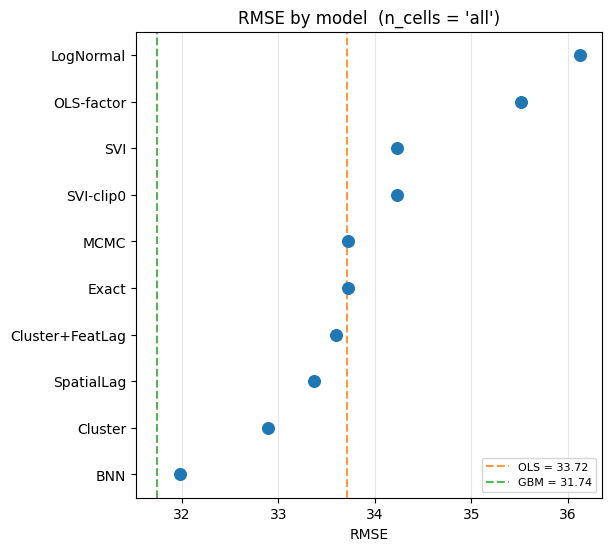

In [25]:
metrics_df = (all_metrics_df()
              .sort_values(["model", "n_train"])
              .reset_index(drop=True))
print(metrics_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

metric_dotplot(MODELS, metric="RMSE")

### 7.2 What the model learned

On a linear model, three ways of fitting it — exact, sampling (NUTS), and the fast variational approximation (SVI) — should all recover the same coefficients. Where they agree, the cheap method can be trusted; where they disagree, it cannot. This is the check that licenses using fast inference for the heavier models later.

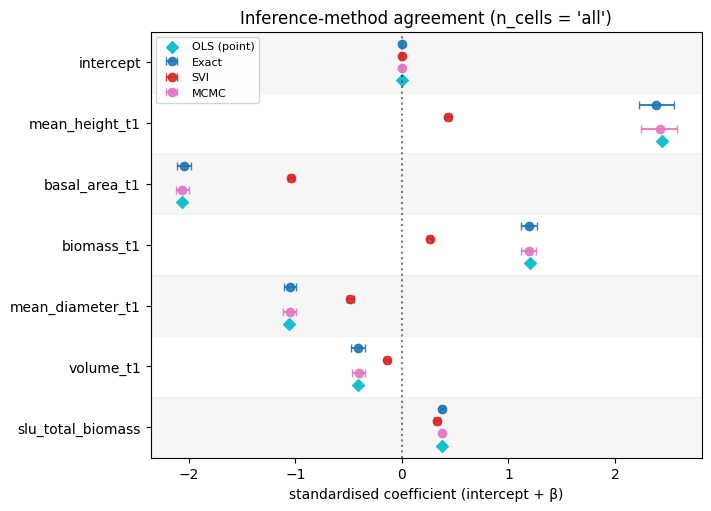

In [26]:
inference_forest_plot(MODELS, FEATURE_NAMES)

### 7.3 Uncertainty calibration

Calibration asks whether a model's stated uncertainty is honest: when it claims to be 90 % sure, is it right 90 % of the time? Only the Bayesian models can be scored here — OLS and GBM give a single number with no spread. The coverage curve measures how honest each model is; the density overlay shows the shape of the predicted spread against the real one.

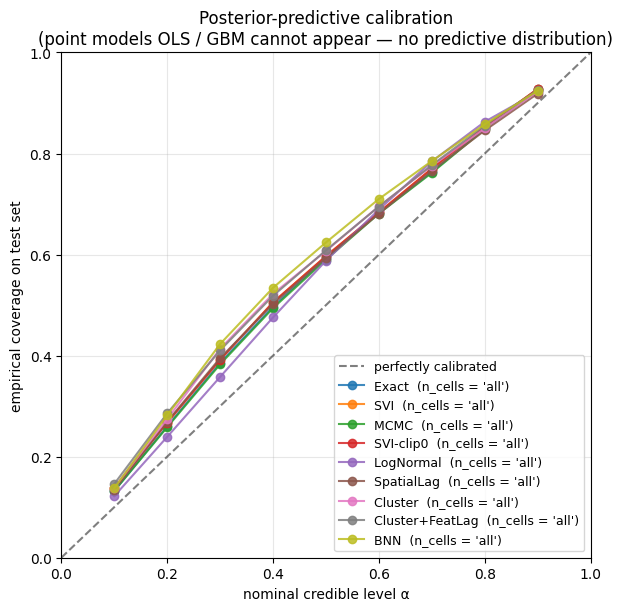

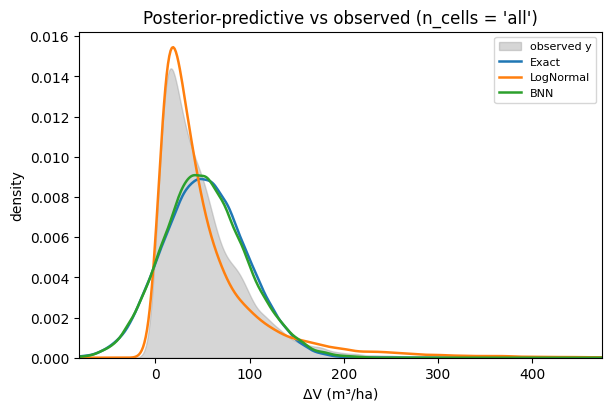

In [27]:
calibration_figure(MODELS, slice_step)
ppc_density_overlay(MODELS, slice_step, names=["Exact", "LogNormal", "BNN"])

In [28]:
# Supporting numbers for the §4.3 report prose: empirical coverage at key levels.
import numpy as np
alphas = np.arange(0.1, 1.0, 0.1)
rows = [(n, c) for n in MODELS
        if (c := posterior_predictive_coverage(MODELS, slice_step, n, "all", alphas)) is not None]
print(f"{'model':<16}{'α=0.5':>9}{'α=0.8':>9}{'α=0.9':>9}")
for n, c in rows:
    print(f"{n:<16}{c[4]:>9.3f}{c[7]:>9.3f}{c[8]:>9.3f}")
M = np.array([c for _, c in rows])
print("\nacross-model spread per nominal level:")
for j, a in enumerate(alphas):
    print(f"  α={a:.1f}:  {M[:,j].min():.3f}–{M[:,j].max():.3f}   (spread {M[:,j].max()-M[:,j].min():.3f})")

model               α=0.5    α=0.8    α=0.9
Exact               0.594    0.850    0.928
SVI                 0.597    0.853    0.928
MCMC                0.590    0.848    0.925
SVI-clip0           0.597    0.853    0.928
LogNormal           0.588    0.863    0.922
SpatialLag          0.594    0.846    0.919
Cluster             0.607    0.850    0.923
Cluster+FeatLag     0.608    0.855    0.926
BNN                 0.624    0.858    0.924

across-model spread per nominal level:
  α=0.1:  0.122–0.146   (spread 0.024)
  α=0.2:  0.239–0.286   (spread 0.046)
  α=0.3:  0.358–0.423   (spread 0.065)
  α=0.4:  0.476–0.534   (spread 0.059)
  α=0.5:  0.588–0.624   (spread 0.036)
  α=0.6:  0.681–0.710   (spread 0.029)
  α=0.7:  0.762–0.785   (spread 0.023)
  α=0.8:  0.846–0.863   (spread 0.017)
  α=0.9:  0.919–0.928   (spread 0.009)


### 7.4 Where residuals concentrate

If a model's errors cluster in space, there is structure it has not captured. Moran's I measures that clustering — the ranking shows which models leave the least behind, and the paired maps show what that looks like on the ground.

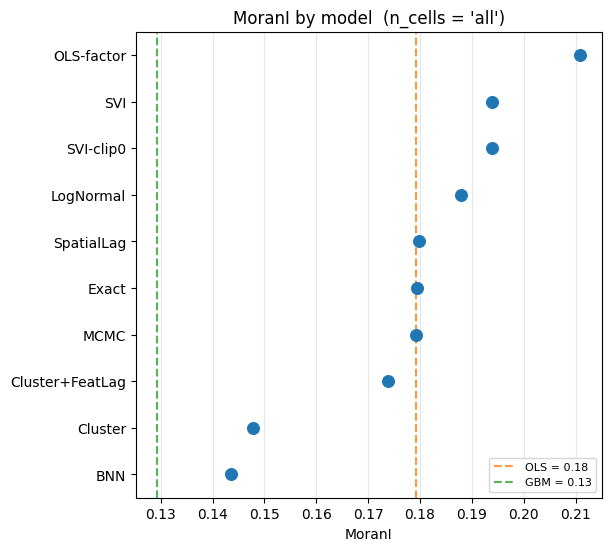

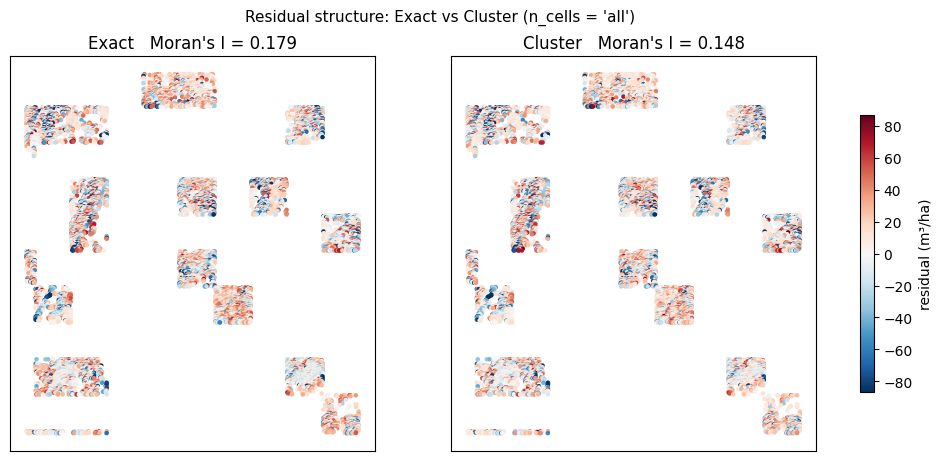

In [29]:
metric_dotplot(MODELS, metric="MoranI")
residual_comparison_maps(MODELS, slice_step, left="Exact", right="Cluster")

### 7.5 Wall-clock compute

Compute is the budget. A model that is too slow per fit cannot sit in a scenario pipeline, however good its other numbers. This tracks wall-clock time as the training set grows.

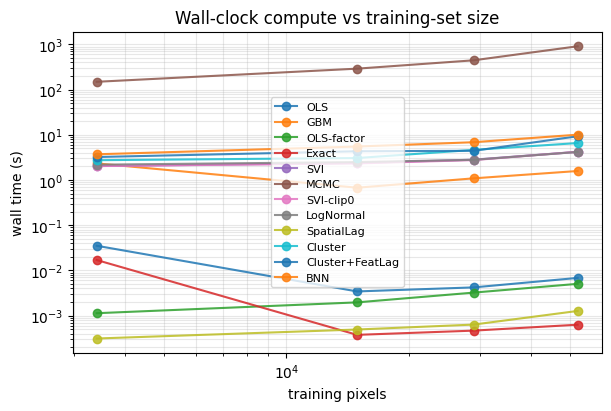

In [30]:
walltime_figure(MODELS)

### 7.6 Synthesis

Two axes at once: point accuracy barely separates the models, but the spatial-structure axis does. That gap is the case for looking past RMSE — and the basis for the recommendation in the discussion.

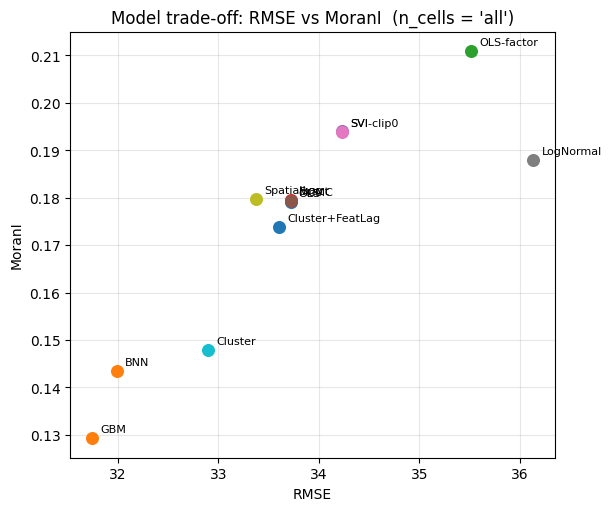

In [31]:
tradeoff_scatter(MODELS, x="RMSE", y="MoranI")